# NOTEBOOK: Classification Model Comparison

Compare all classification models on Titanic dataset:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - K-Nearest Neighbors (KNN)
 - Naive Bayes
 - Support Vector Machine (SVM)

## Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import (
    SKLearnLogisticRegression,
    SKLearnDecisionTreeClassifier,
    SKLearnRandomForestClassifier,
    SKLearnKNNClassifier,
    SKLearnNaiveBayes,
    SKLearnSVMClassifier
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2025-12-31 00:29:33.897898: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load & Preprocess Data

In [3]:
X, y = data_loader.load_titanic()

# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=True, encode_categorical=True)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Training set: {X_train_proc.shape}")
print(f"Test set: {X_test_proc.shape}")


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 5 columns
   Nominal categorical: 2 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...
   ✓ Applied most_frequent imputation
   ✓ One-hot encoding 2 nominal columns...
   → Created 5 one-hot features

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 5 features

Final shape: 712 rows × 10 features

Training set: (712, 10)
Test set: (179, 10)


## Train All Models

In [4]:
models = {
    'Logistic Regression': SKLearnLogisticRegression(random_state=42),
    'Decision Tree': SKLearnDecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': SKLearnRandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': SKLearnKNNClassifier(n_neighbors=5),
    'Naive Bayes': SKLearnNaiveBayes(variant='gaussian'),
    'SVM': SKLearnSVMClassifier(kernel='rbf', C=1.0, random_state=42)
}

results = {
    'Model': [],
    'Train Acc': [],
    'Test Acc': [],
    'Overfit': []
}

print("\nTraining models...")
for name, model in models.items():
    # Train
    model.fit(X_train_proc, y_train)
    
    # Evaluate
    train_acc = model.score(X_train_proc, y_train)
    test_acc = model.score(X_test_proc, y_test)
    overfit = train_acc - test_acc
    
    # Store
    results['Model'].append(name)
    results['Train Acc'].append(train_acc)
    results['Test Acc'].append(test_acc)
    results['Overfit'].append(overfit)
    
    print(f"  {name}: Train={train_acc:.4f}, Test={test_acc:.4f}")


Training models...
  Logistic Regression: Train=0.8020, Test=0.8101
  Decision Tree: Train=0.8511, Test=0.7989
  Random Forest: Train=0.9789, Test=0.8101
  KNN: Train=0.8596, Test=0.8101
  Naive Bayes: Train=0.7963, Test=0.7765
  SVM: Train=0.8399, Test=0.8156


## Compare Results


Model Comparison (sorted by Test Accuracy):
                 Model  Train Acc  Test Acc   Overfit
5                  SVM   0.839888  0.815642  0.024245
0  Logistic Regression   0.801966  0.810056 -0.008090
2        Random Forest   0.978933  0.810056  0.168877
3                  KNN   0.859551  0.810056  0.049495
1        Decision Tree   0.851124  0.798883  0.052241
4          Naive Bayes   0.796348  0.776536  0.019812


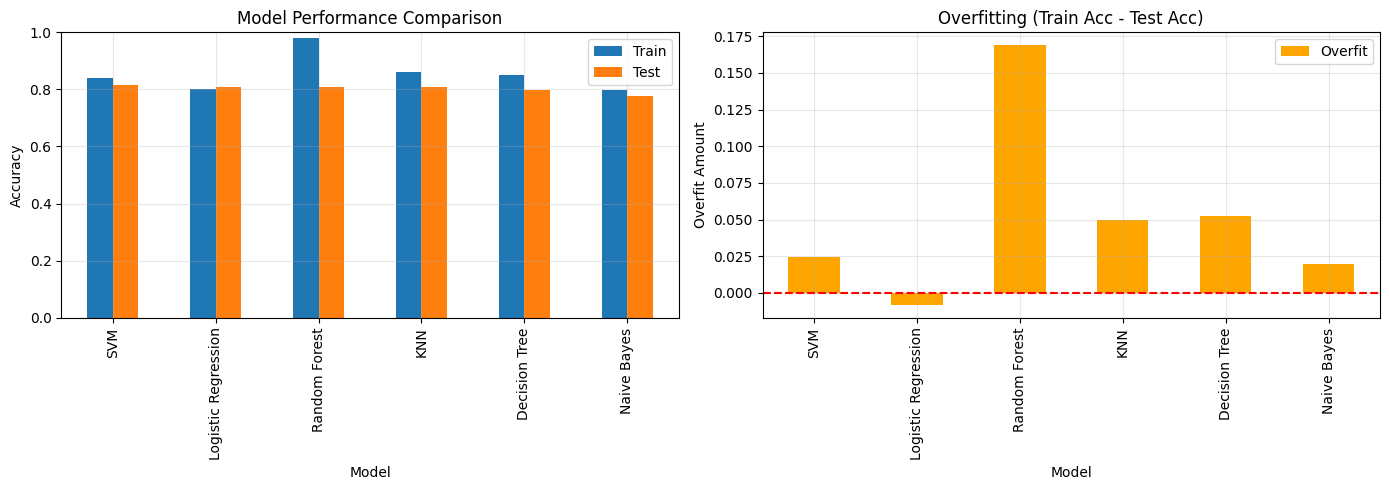

In [5]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Acc', ascending=False)

print("\nModel Comparison (sorted by Test Accuracy):")
print(results_df)

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
results_df.plot(x='Model', y=['Train Acc', 'Test Acc'], kind='bar', ax=ax[0])
ax[0].set_title('Model Performance Comparison')
ax[0].set_ylabel('Accuracy')
ax[0].legend(['Train', 'Test'])
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim([0, 1])

# Overfitting
results_df.plot(x='Model', y='Overfit', kind='bar', ax=ax[1], color='orange')
ax[1].set_title('Overfitting (Train Acc - Test Acc)')
ax[1].set_ylabel('Overfit Amount')
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusions

In [6]:
best_model = results_df.iloc[0]

print("\n" + "="*70)
print("FINAL CONCLUSIONS")
print("="*70)
print(f"Best model: {best_model['Model']}")
print(f"  Test Accuracy: {best_model['Test Acc']:.4f}")
print(f"  Overfit: {best_model['Overfit']:.4f}")


FINAL CONCLUSIONS
Best model: SVM
  Test Accuracy: 0.8156
  Overfit: 0.0242
